In [42]:
# -----------------------------
# A/B Test Analysis of Subscription Screen Optimization
# -----------------------------

In [43]:
""" Öncelikle, neyi test ettiğimizi hatırlayalım:
Grup A: Bu kullanıcılara uygulamanın premium özelliklerine erişmek için $4.99’a abonelik satın almayı öneriyoruz.
Grup B: Aynı aboneliği %50 indirimli bir teklif olarak sunuyoruz. """

' Öncelikle, neyi test ettiğimizi hatırlayalım:\nGrup A: Bu kullanıcılara uygulamanın premium özelliklerine erişmek için $4.99’a abonelik satın almayı öneriyoruz.\nGrup B: Aynı aboneliği %50 indirimli bir teklif olarak sunuyoruz. '

In [44]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.proportion import proportions_ztest
import statsmodels.api as sm

In [46]:
# Veri yükleme
# Drive’daki dosyayı Colab’de aç
# CSV dosyanı tablo (DataFrame) haline getirdi

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/ab_test_data.csv")

# İlk 5 satırı getir
df.head()

,user_id,timestamp,test_group,conversion
0,7f6833e6-1141-4f20-b4b2-f1e31019b1fd,2023-07-04 4:40:56,a,0
1,e6a6e960-d3f3-4074-a516-ba1e609b211e,2023-07-06 0:26:45,b,0
2,4d3fbfa5-6847-410a-bac2-477f01d5f400,2023-07-10 20:24:34,b,0
3,361457d9-a044-48f7-981c-d67dc3861679,2023-07-20 7:04:50,b,0
4,285cd63d-7d03-427f-a062-1fa2dd2e77d6,2023-07-19 23:27:50,b,0


In [47]:
# 1.Görev:
# -----------------------------
# Dosyadan verileri okuyun ve A/B testinin sonuçları hakkında bilgileri çıkarın:
# A ve B gruplarındaki kullanıcı sayısı;
# A ve B gruplarındaki dönüşüm sayısı;
# A ve B gruplarındaki dönüşüm oranı;
# Testin başlangıç tarihi, bitiş tarihi ve testin süresi (gün olarak).

In [48]:
# Grupları ayırma

A = df[df["test_group"] == "a"]
B = df[df["test_group"] == "b"]

In [49]:
# Kullanıcı sayısı
# Kaç kişi A ve B’de var

n_A = len(A)
n_B = len(B)

print(f"Grup A kullanıcı sayısı: {n_A}")
print(f"Grup B kullanıcı sayısı: {n_B}")

Grup A kullanıcı sayısı: 10013
Grup B kullanıcı sayısı: 9985


In [50]:
# Satın alma sayısı
# 1 = satın aldı 0 = almadı
# toplarsan direkt satın alan sayısı çıkar

conv_A = A["conversion"].sum()
conv_B = B["conversion"].sum()

print(f"Grup A dönüşüm sayısı: {conv_A}")
print(f"Grup B dönüşüm sayısı: {conv_B}")

Grup A dönüşüm sayısı: 611
Grup B dönüşüm sayısı: 889


In [51]:
# Conversion rate

cr_A = conv_A / n_A
cr_B = conv_B / n_B

print(f"Grup A dönüşüm oranı: {cr_A:.4f}\n")
print(f"Grup B dönüşüm oranı: {cr_B:.4f}\n")

Grup A dönüşüm oranı: 0.0610

Grup B dönüşüm oranı: 0.0890



In [52]:
# Tarih formatını düzelt

df["timestamp"] = pd.to_datetime(df["timestamp"])


In [53]:
# Tarih kısmı
# Test kaç gün sürmüş

start_date = df["timestamp"].min()
end_date = df["timestamp"].max()
duration = (end_date - start_date).days + 1

print(f"Test başlangıç tarihi: {start_date}")
print(f"Test bitiş tarihi: {end_date}")
print(f"Test süresi (gün): {duration}")

Test başlangıç tarihi: 2023-07-03 01:42:34
Test bitiş tarihi: 2023-07-25 01:41:19
Test süresi (gün): 22


In [54]:
# -----------------------------
# 1.Görev: Sonuçları yazdır
# -----------------------------

In [55]:
print("=== A/B TEST SONUÇLARI ===\n")

print(f"Grup A kullanıcı sayısı: {n_A}")
print(f"Grup A dönüşüm sayısı: {conv_A}")
print(f"Grup A dönüşüm oranı: {cr_A:.4f}\n")

print(f"Grup B kullanıcı sayısı: {n_B}")
print(f"Grup B dönüşüm sayısı: {conv_B}")
print(f"Grup B dönüşüm oranı: {cr_B:.4f}\n")

print(f"Test başlangıç tarihi: {start_date}")
print(f"Test bitiş tarihi: {end_date}")
print(f"Test süresi (gün): {duration}")

=== A/B TEST SONUÇLARI ===

Grup A kullanıcı sayısı: 10013
Grup A dönüşüm sayısı: 611
Grup A dönüşüm oranı: 0.0610

Grup B kullanıcı sayısı: 9985
Grup B dönüşüm sayısı: 889
Grup B dönüşüm oranı: 0.0890

Test başlangıç tarihi: 2023-07-03 01:42:34
Test bitiş tarihi: 2023-07-25 01:41:19
Test süresi (gün): 22


In [56]:
# 2.Görev:
# -----------------------------
# Hipotez testleri için istediğiniz istatistiksel kriteri seçin ve istatistik değerlerini ve p-değerini hesaplayın.
# Null hipotezini reddedip edemeyeceğimizi kontrol edin.
# Hangi kriteri kullandığınızı belirtmeyi unutmayın

In [57]:
# HİPOTEZ TESTİ (Two-proportion z-test)

# p-value = Gördüğüm fark gerçekten mi var yoksa şans eseri mi?
# H0: A ve B arasında fark yok (p > 0.05)
# H1: A ve B arasında fark var (two-sided) (p < 0.05)

count = [conv_A, conv_B]
nobs = [n_A, n_B]

stat, pval = proportions_ztest(count, nobs, alternative='two-sided')

print(f"Z istatistiği: {stat:.4f}")
print(f"P-değeri: {pval:.4f}\n")

Z istatistiği: -7.5197
P-değeri: 0.0000



In [58]:
# -----------------------------
# 2.Görev: Sonuçları yazdır
# -----------------------------

In [59]:
print("=== HİPOTEZ TESTİ SONUÇLARI ===\n")

print(f"Test türü: Two-proportion z-test")
print(f"Z istatistiği: {stat:.4f}")
print(f"P-değeri: {pval:.4f}\n")

=== HİPOTEZ TESTİ SONUÇLARI ===

Test türü: Two-proportion z-test
Z istatistiği: -7.5197
P-değeri: 0.0000



In [60]:
# Karar

alpha = 0.05

if pval < alpha:
    print("SONUÇ: p < 0.05 → Null hipotezi REDDEDİLİR")
    print("Yani A ve B arasında istatistiksel olarak anlamlı fark VAR ✅")
else:
    print("SONUÇ: p ≥ 0.05 → Null hipotezi REDDEDİLEMEZ")
    print("Yani A ve B arasında istatistiksel olarak anlamlı fark YOK ❌")

SONUÇ: p < 0.05 → Null hipotezi REDDEDİLİR
Yani A ve B arasında istatistiksel olarak anlamlı fark VAR ✅


In [61]:
# 3.Görev:
# -----------------------------
# 95% güven aralıkları ile gruplar arasındaki ortalama değerlerin karşılaştırılması için bir görselleştirme oluşturun.

In [62]:
# 95% Confidence Interval hesapla
# Şu demek: Gerçek conversion rate büyük ihtimalle bu aralıkta.
# %100 emin olamazsın ama %95 güvenle konuşabilirsin

confint_A = sm.stats.proportion_confint(conv_A, n_A, alpha=0.05, method="normal")
confint_B = sm.stats.proportion_confint(conv_B, n_B, alpha=0.05, method="normal")

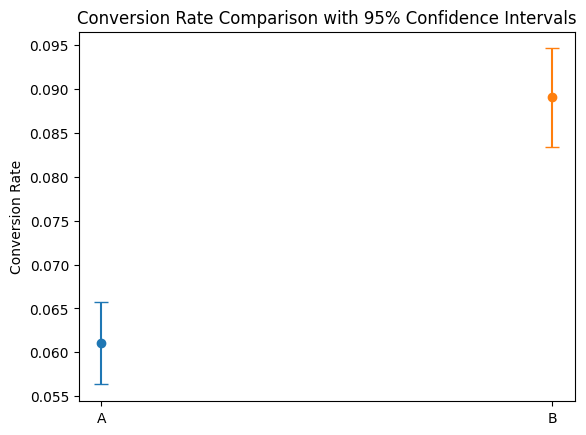

In [63]:
# Grafik
# Nokta → conversion rate (%17, %20 gibi)
# Çubuklar → belirsizlik (confidence interval)

plt.figure()

plt.errorbar(["A"], [cr_A],
             yerr=[[cr_A - confint_A[0]], [confint_A[1] - cr_A]],
             fmt='o', capsize=5)

plt.errorbar(["B"], [cr_B],
             yerr=[[cr_B - confint_B[0]], [confint_B[1] - cr_B]],
             fmt='o', capsize=5)

plt.title("Conversion Rate Comparison with 95% Confidence Intervals")
plt.ylabel("Conversion Rate")

plt.show()

# Eğer çubuklar AYRIYSA: fark güçlü → anlamlı olabilir
# Eğer çubuklar ÜST ÜSTEYSE: fark zayıf → büyük ihtimalle anlamsız


In [64]:
# 4.Görev:
# -----------------------------
# Bu konuda okuduğunuz önerilere göre A/B testinin sonuçları hakkında çıkarımlar hazırlayın.

In [65]:
# Sonuçlar ve Çıkarımlar

"""Gerçekleştirilen A/B testi kapsamında, kontrol grubu (A) ile “%50 indirim” mesajı içeren varyant (B) karşılaştırılmıştır.

Elde edilen sonuçlara göre:

* Grup A dönüşüm oranı: %6.10
* Grup B dönüşüm oranı: %8.90

Bu sonuçlar, indirim mesajı içeren Grup B’nin, kontrol grubuna kıyasla daha yüksek bir dönüşüm oranına sahip olduğunu göstermektedir.

İki oran karşılaştırması için kullanılan two-proportion z-test sonucunda z istatistiği -7.5197 ve p-değeri ≈ 0.0000 olarak bulunmuştur.
p-değerinin 0.05’ten oldukça küçük olması nedeniyle null hipotezi reddedilmiştir.
Bu da iki grup arasındaki farkın istatistiksel olarak anlamlı olduğunu göstermektedir.

Test süresi toplam 22 gün olup, bu süre hem yeterli örneklem büyüklüğüne ulaşılması hem de kullanıcı davranışındaki haftalık değişimlerin dengelenmesi açısından yeterlidir.

Sonuçlar, “%50 indirim” mesajının kullanıcıların satın alma davranışı üzerinde güçlü ve pozitif bir etki yarattığını açıkça göstermektedir.
Grup B’nin dönüşüm oranı, Grup A’ya göre yaklaşık %45 oranında daha yüksektir (göreli artış)."""

# Karar
"""
Elde edilen bulgular doğrultusunda, “%50 indirim” mesajı içeren abonelik ekranının (Grup B) tüm kullanıcılara uygulanması önerilmektedir.

Bu test, doğru mesajlama stratejisinin kullanıcı davranışını önemli ölçüde değiştirebildiğini ve A/B testlerinin veri odaklı karar alma sürecinde
kritik bir rol oynadığını göstermektedir.
"""

'\nElde edilen bulgular doğrultusunda, “%50 indirim” mesajı içeren abonelik ekranının (Grup B) tüm kullanıcılara uygulanması önerilmektedir.\n\nBu test, doğru mesajlama stratejisinin kullanıcı davranışını önemli ölçüde değiştirebildiğini ve A/B testlerinin veri odaklı karar alma sürecinde \nkritik bir rol oynadığını göstermektedir.\n'

In [66]:
# Bonus Görevi:
# Zaman içinde dönüşüm oranının değişimini gösteren bir grafik oluşturun.
# Bu sefer olayın gerçekleşme zamanı ile ilgili verilerimizin olduğunu unutmayın.

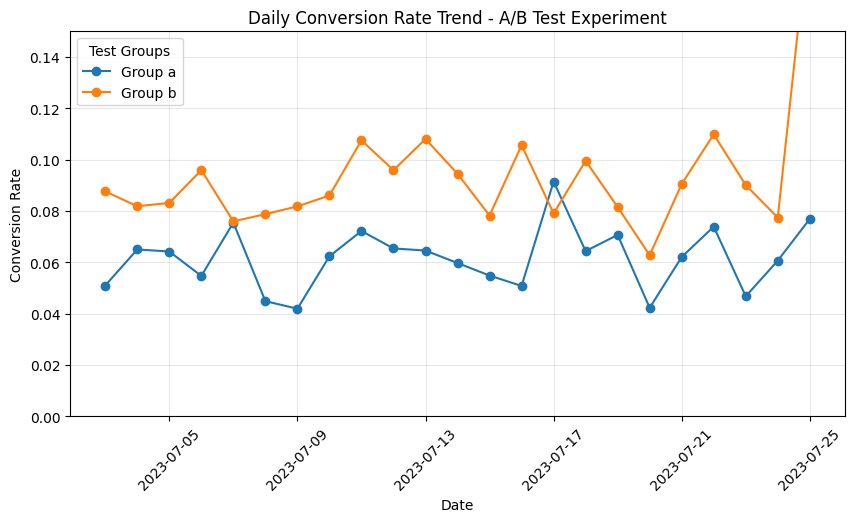

In [67]:
# Sadece gün bilgisi al
df["date"] = df["timestamp"].dt.date

# Günlük conversion rate hesapla
# Gün gün: A grubunun conversion’ı ve B grubunun conversion’ı
df_daily = df.groupby(["date", "test_group"])["conversion"].mean().reset_index()

# Grafik çiz

# Yeni bir grafik başlatır ve boyutlar
plt.figure(figsize=(10,5))

# df_daily içindeki grupları alır
# unique() → sadece benzersiz değerler
for group in df_daily["test_group"].unique():
    subset = df_daily[df_daily["test_group"] == group]
    # X ekseni → tarih (date) Y ekseni → conversion rate marker → çizgi + nokta label → açıklama (A mı B mi)
    plt.plot(subset["date"], subset["conversion"], marker="o", label=f"Group {group}")

plt.grid(True, alpha=0.3)
plt.title("Daily Conversion Rate Trend - A/B Test Experiment")
plt.xlabel("Date")
# Y eksenini sabitle
plt.ylim(0, 0.15)
plt.ylabel("Conversion Rate")
# Tarihleri 45 derece eğiyor. Üst üste binmesin, okunabilir olsun
plt.xticks(rotation=45)
# Legend (açıklama kutusu)
plt.legend(title="Test Groups")

plt.show()